In [1]:
from pathlib import Path

from src import data_processing as dp
from src import inference as inf
from src import model_builder as mb
from src import postprocessing as pp
from src import viz
from src import regression as reg
from src.config import MCMCConfig

g++ not available, if using conda: `conda install gxx`
C:\Users\gbedo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\arviz\__init__.py:110: MigrationWarning: arviz.InferenceData is no longer available on the arviz package; ArviZ now uses xarray's DataTree for the same role. See the migration guide: https://python.arviz.org/en/latest/user_guide/migration_guide.html#datatree
  warnings.warn(


# UN Voting Analysis

## Overview

This notebook runs the complete Bayesian model for estimating countries' ideological positions from UN General Assembly voting data.

The analysis proceeds in four main steps:

1. **Prepare the voting data**
2. **Build the Bayesian model**
3. **Sample from the posterior distribution**
4. **Extract, save, and visualize the results**

The final section links the estimated ideological distance between Australia and the United States to Australia's sentiment toward the United States in foreign-affairs texts.

## 1. Data preparation

The first step loads the UN voting data and transforms it into the structure required by the model.

Countries, UN sessions, and resolutions are encoded as integer indices. These indices are used by the probabilistic model to represent the different dimensions of the voting data.

The resulting objects provide:

* the encoded voting observations;
* mappings between countries, sessions, and resolutions;
* the year associated with each UN session;
* the dimensions required to construct the model.

Note that there are several type of votes that you should restrain to for faster calculations. This can be set in the parameter `vote_type` in the function `load_raw_votes`.

The types of votes available are:
* Important;
* MiddleEast;
* HumanRights;
* Colonial;
* Nuclear;
* Economic;
* Disarmament.

In [2]:
cfg = MCMCConfig(project_root=Path.cwd(), random_seed=42)

raw_votes = dp.load_raw_votes(cfg, vote_type="Important", verbose=False)
votes_df = dp.transform_votes(raw_votes)

COUNTRY_TO_IDX, SESSION_TO_IDX, RCID_TO_IDX = dp.encoder_dictionnaries(votes_df)
votes_encoded = dp.structure_vote_table(votes_df, COUNTRY_TO_IDX, SESSION_TO_IDX, RCID_TO_IDX)
session_years = dp.build_session_years(votes_encoded)

num_countries = len(COUNTRY_TO_IDX)
num_sessions = len(SESSION_TO_IDX)
num_resolutions = len(RCID_TO_IDX)

c:\Users\gbedo\OneDrive\Bureau\ENSAE 2A Internship\political_manifesto_analysis\un_voting_analysis\src\data_processing.py:257: DtypeWarning: Columns (0: year, 1: descr) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv(votes_path, index_col=0)


## 2. Model construction

The Bayesian model is constructed from the encoded voting data.

Before building the model, initial values for the resolution-specific parameters (`beta`) are generated from the observed voting patterns. These initial values are subsequently provided to the sampling procedure.

The model estimates country-specific ideological positions over time while accounting for resolution-specific effects.

In [3]:
beta_init = mb.build_beta_initial_values(
    votes=votes_df,
    rcid_to_idx=RCID_TO_IDX,
    num_resolutions=num_resolutions,
)

model = mb.build_model(
    country_idx=votes_encoded["country_idx"].values,
    session_idx=votes_encoded["session_idx"].values,
    resolution_idx=votes_encoded["resolution_idx"].values,
    observed_vote=votes_encoded["vote_ordinal"].values,
    num_countries=num_countries,
    num_sessions=num_sessions,
    num_resolutions=num_resolutions,
    country_to_idx=COUNTRY_TO_IDX,
)

## 3. Posterior sampling

The model is estimated using Markov Chain Monte Carlo (MCMC).

The sampling configuration used in this notebook is intentionally small for development and testing:

* 4 chains;
* 50 posterior draws per chain;
* 20 tuning iterations;
* target acceptance rate of 0.9.

For a final analysis, these parameters should be increased to obtain a more reliable approximation of the posterior distribution.

The output is an ArviZ `InferenceData` object containing the posterior samples.

In [4]:
idata = inf.run_sampling(
    model,
    beta_init=beta_init,
    draws=50,
    tune=10,
    chains=4,
    target_accept=0.9
    #random_seed=cfg.random_seed,
)

Only 50 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_theta, theta_0, theta_innov, beta, cutpoint_1, cutpoint_distance]


Output()

Sampling 4 chains for 10 tune and 50 draw iterations (40 + 200 draws total) took 580 seconds.
The number of samples is too small to check convergence reliably.


## 4. Results

The posterior samples are transformed into two summary datasets:

* **ThetaSummary**: country-level ideological positions by UN session/year;
* **BetaSummary**: resolution-level parameters.

Both datasets are saved in the processed-data directory so that they can be reused without rerunning the Bayesian model.

The first visualization shows the estimated ideological trajectories of selected countries over time.

In [5]:
theta_summary = pp.extract_theta_summary(idata, COUNTRY_TO_IDX, session_years)
beta_summary = pp.extract_beta_summary(idata, RCID_TO_IDX)

theta_summary.to_csv(cfg.processed_data_dir / "ThetaSummary.csv", index=False)
beta_summary.to_csv(cfg.processed_data_dir / "BetaSummary.csv", index=False)

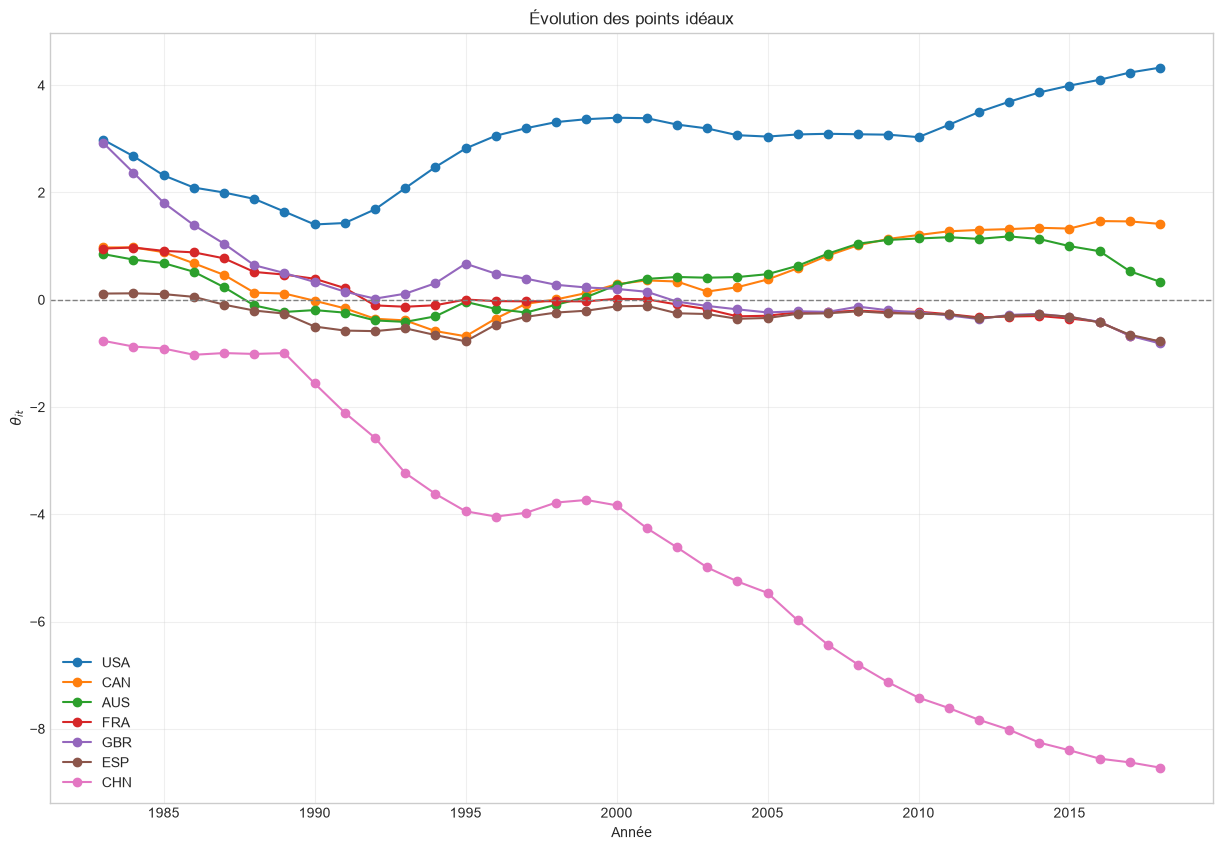

In [6]:
viz.plot_country_trajectories(theta_summary, countries=["USA", "CAN", "AUS", "FRA", "GBR","ESP", "CHN"], conf_intervals=False)

# Linking ideological distance and sentiment

The second part of the notebook connects the two complementary components of the project:

* the **UN voting model**, which estimates ideological positions;
* the **topic and sentiment analysis**, which measures how political parties discuss other countries in foreign-affairs texts.

The example focuses on **Australia's relationship with the United States**.

## 5. Australian sentiment toward the United States

The sentiment scores represent the average sentiment expressed toward the United States in Australian political manifestos.

The scores used below are currently entered directly as a dictionary indexed by year.

These values can instead be generated by the `sentiment_analysis` pipeline developed in the companion `topic_sentiment_analysis` project.

Because manifestos are available only for election years, the sentiment value is carried forward to the subsequent years until the next available manifesto.

This is a bold choice but it does not mean that it is the good one. One must eventually think about better ways to do this

In [7]:
australia_sentiment_towards_usa = {1961: -0.5423,
 1963: 0.6031888888888889,
 1966: 0.4222821428571429,
 1969: 0.2819666666666667,
 1972: 0.61315,
 1974: 0.49305000000000004,
 1975: 0.6597,
 1977: 0.6611750000000001,
 1980: 0.28552857142857146,
 1983: 0.55865,
 1984: 0.26955,
 1987: 0.819475,
 1990: 0.307525,
 1993: None,
 1996: 0.5122857142857143,
 1998: None,
 2001: -0.18579999999999997,
 2004: 0.560075,
 2007: 0.40775,
 2010: 0.08708333333333329,
 2013: 0.4957833333333333,
 2016: 0.7609999999999999,
 2019: 0.19785694444444443,
 2022: 0.36210213675213676}

aus_test = {1961: -0.5423,
 1962: -0.5423,
 1963: 0.6031888888888889,
 1964: 0.6031888888888889,
 1965: 0.6031888888888889,
 1966: 0.4222821428571429,
 1967: 0.4222821428571429,
 1968: 0.4222821428571429,
 1969: 0.2819666666666667,
 1970: 0.2819666666666667,
 1971: 0.2819666666666667,
 1972: 0.61315,
 1973: 0.61315,
 1974: 0.49305000000000004,
 1975: 0.6597,
 1976: 0.6597,
 1977: 0.6611750000000001,
 1978: 0.6611750000000001,
 1979: 0.6611750000000001,
 1980: 0.28552857142857146,
 1981: 0.28552857142857146,
 1982: 0.28552857142857146,
 1983: 0.55865,
 1984: 0.26955,
 1985: 0.26955,
 1986: 0.26955,
 1987: 0.819475,
 1988: 0.819475,
 1989: 0.819475,
 1990: 0.307525,
 1991: 0.307525,
 1992: 0.307525,
 1993: 0.307525,
 1994: 0.307525,
 1995: 0.307525,
 1996: 0.5122857142857143,
 1997: 0.5122857142857143,
 1998: 0.5122857142857143,
 1999: 0.5122857142857143,
 2000: 0.5122857142857143,
 2001: -0.18579999999999997,
 2002: -0.18579999999999997,
 2003: -0.18579999999999997,
 2004: 0.560075,
 2005: 0.560075,
 2006: 0.560075,
 2007: 0.40775,
 2008: 0.40775,
 2009: 0.40775,
 2010: 0.08708333333333329,
 2011: 0.08708333333333329,
 2012: 0.08708333333333329,
 2013: 0.4957833333333333,
 2014: 0.4957833333333333,
 2015: 0.4957833333333333,
 2016: 0.7609999999999999,
 2017: 0.7609999999999999,
 2018: 0.7609999999999999,
 2019: 0.19785694444444443,
 2020: 0.19785694444444443,
 2021: 0.19785694444444443,
 2022: 0.36210213675213676}

# The scores can be computed via sentiment_analyzer.ipynb. Then you shall copy them here. Do not forget to replace None by None.

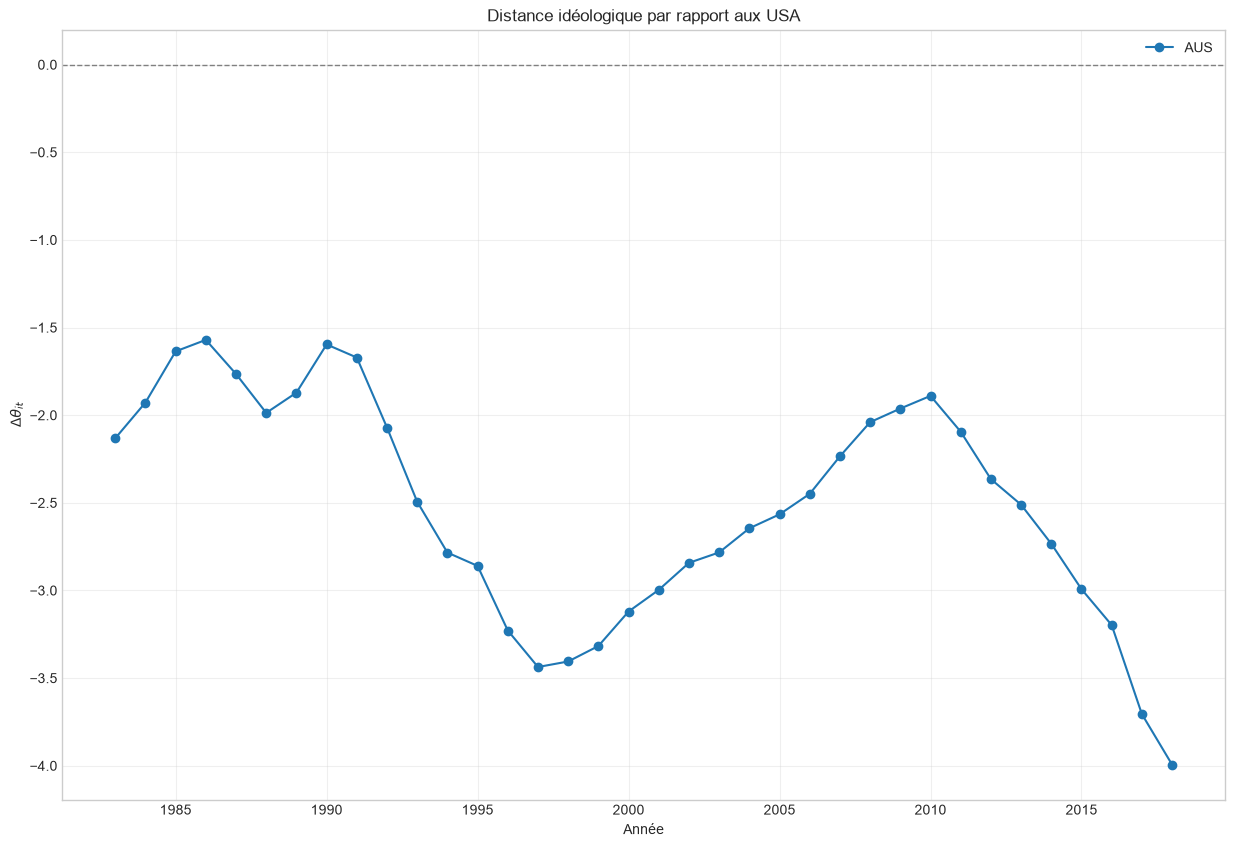

In [8]:
distance_USA = viz.plot_distance_to_USA(theta_summary, countries=["AUS"])

In [44]:
distance_USA["country_sentiment_towards_usa"] = distance_USA["year"].map(australia_sentiment_towards_usa)

In [45]:
distance_USA

,country,year,distance_to_usa,country_sentiment_towards_usa
0,AUS,1983,-2.131764,0.558650
1,AUS,1984,-1.927733,0.269550
2,AUS,1985,-1.635891,NaN
3,AUS,1986,-1.570450,NaN
4,AUS,1987,-1.765189,0.819475
5,AUS,1988,-1.986873,NaN
6,AUS,1989,-1.871410,NaN
7,AUS,1990,-1.596489,0.307525
8,AUS,1991,-1.671155,NaN
9,AUS,1992,-2.070733,NaN


In [46]:
filtered_distance_USA = distance_USA.dropna()
filtered_distance_USA

,country,year,distance_to_usa,country_sentiment_towards_usa
0,AUS,1983,-2.131764,0.558650
1,AUS,1984,-1.927733,0.269550
4,AUS,1987,-1.765189,0.819475
7,AUS,1990,-1.596489,0.307525
13,AUS,1996,-3.228525,0.512286
18,AUS,2001,-2.996643,-0.185800
21,AUS,2004,-2.645423,0.560075
24,AUS,2007,-2.234728,0.407750
27,AUS,2010,-1.889887,0.087083
30,AUS,2013,-2.510858,0.495783


## 6. Ideological distance from the United States

The next step extracts Australia's ideological distance from the United States from the estimated country positions.

This produces a yearly measure that can be compared with the sentiment series.

The resulting dataframe combines:

* the year;
* Australia's ideological distance from the United States;
* Australia's sentiment toward the United States.

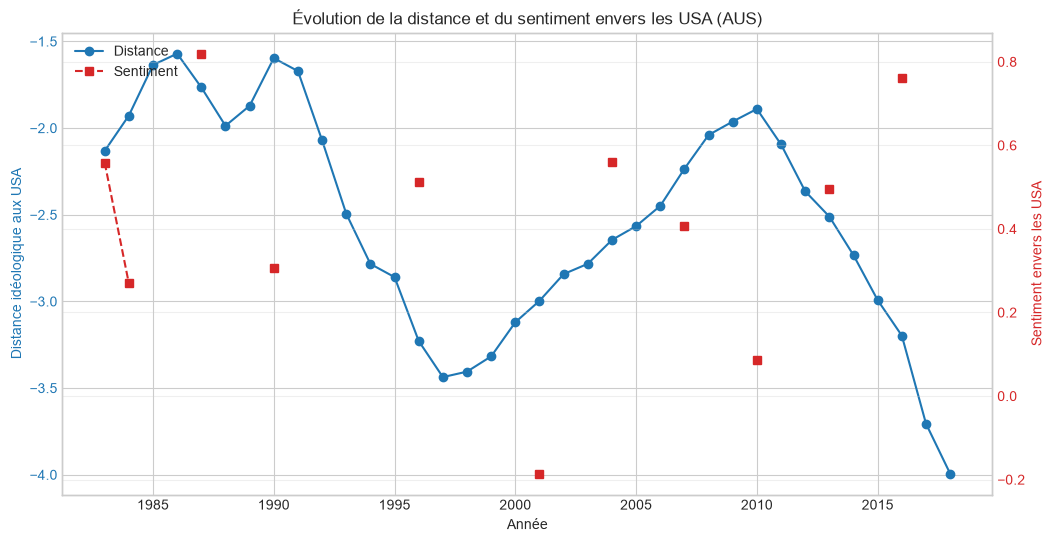

In [47]:
viz.plot_distance_sentiment(distance_USA)

As we can see, there is a lot of years non covered by the method we use for detecting sentiment. This is mainly because manifestos are produced on a frequency lower than the UN Votes frequency. To deal wirth that one can think about interpolating methods.
But the inconvenients of such methods is that it creates artificial data that we cannot really control well.  In this study, we chose then to restrict ourselves to the years where an effective measure of sentiment is available.

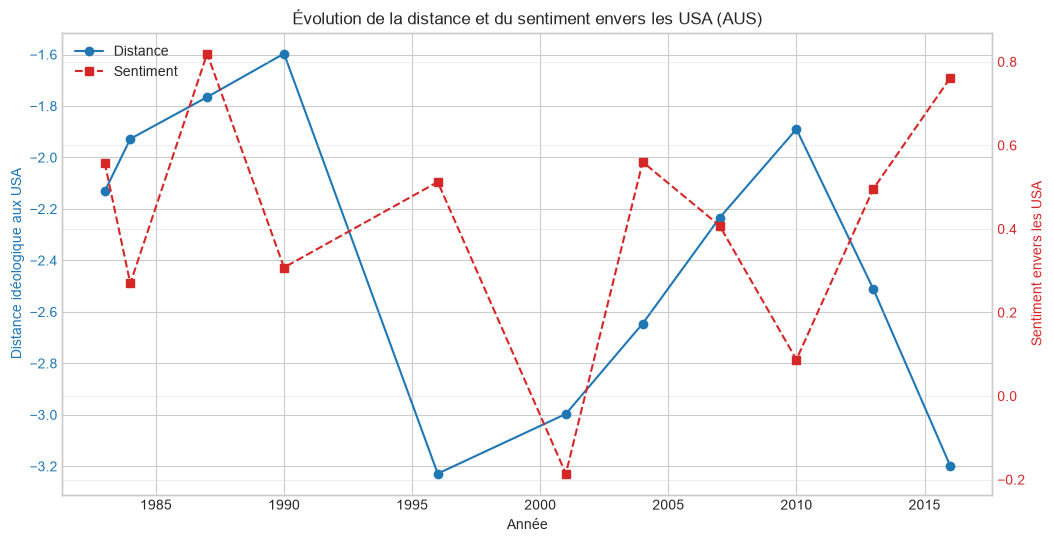

In [48]:
viz.plot_distance_sentiment(filtered_distance_USA)

# Regression Analysis: Sentiment Towards the United States and Ideological Distance

## Objective

This section examines whether a statistical relationship exists between a country's **sentiment towards the United States**, derived from NLP analysis of political manifestos, and its **ideological distance from the United States**.

The objective is exploratory: to assess whether the two measures are associated and whether this relationship varies over time.

### Missing Data

Sentiment is not available for every year, as some manifestos may not contain references to the United States. These observations are kept as `NaN` and are not interpolated.

Each model is therefore estimated using only the observations for which the required variables are available.

---

## Models Tested

Three specifications are considered to capture different temporal relationships.

### Model A — Simple Relationship

[
D_t = \alpha + \beta_0 S_t + \varepsilon_t
]

Tests whether sentiment and ideological distance are associated in the same year.

---

### Model B — One-Year Lagged Sentiment

[
D_t = \alpha + \beta_1 S_{t-1} + \varepsilon_t
]

Tests whether sentiment in the previous year is associated with ideological distance in the current year.

---

### Model C — Two-Year Lagged Sentiment

[
D_t = \alpha + \beta_1 S_{t-1} + \beta_2 S_{t-2} + \varepsilon_t
]

Tests whether sentimentfrom one and two years earlier is associated with current ideological distance.

Comparing the three models allows us to assess whether the relationship is contemporaneous or delayed.

---

## Estimation

All models are estimated using **Ordinary Least Squares (OLS)** with **HC3 heteroskedasticity-robust standard errors**.

For each model, we examine the sentiment coefficient, its p-value and 95% confidence interval, the (R^2), and the number of observations.

Scatter plots with fitted regression lines are also used to visualize the relationships.

---

## Interpretation and Limitations

The coefficients should be interpreted as **associations rather than causal effects**.

The main limitation is the relatively small number of observations resulting from missing sentiment measures. This is particularly important for the lagged models, which further reduce the sample size.

The analysis is therefore primarily **exploratory**, aiming to identify potential relationships between sentiment towards the USA and ideological distance.


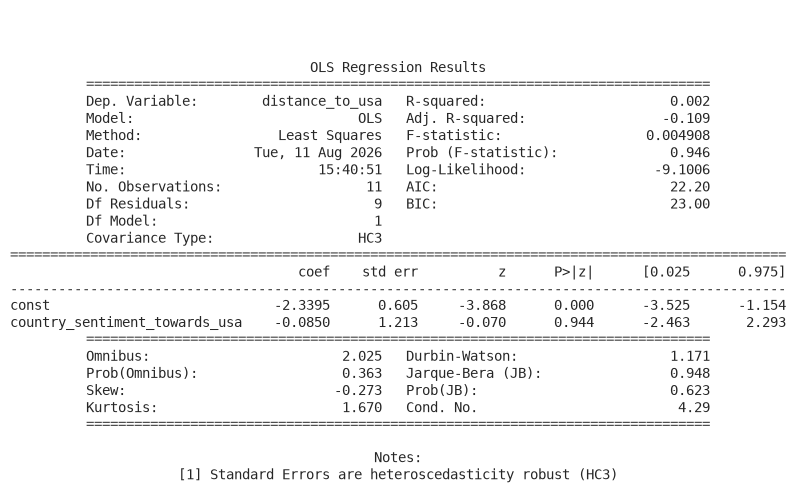

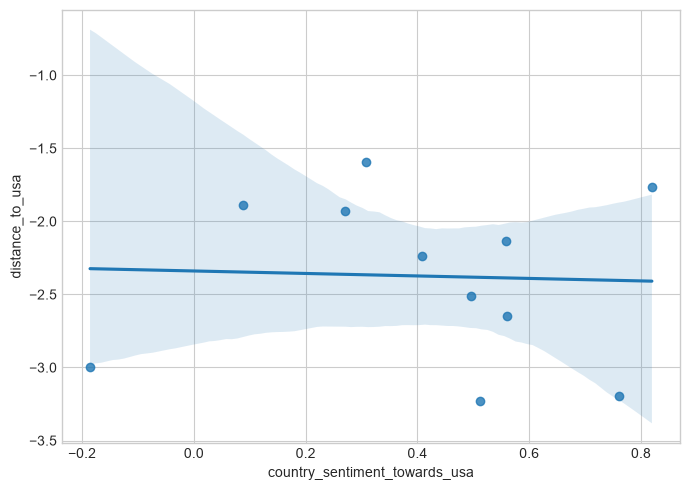

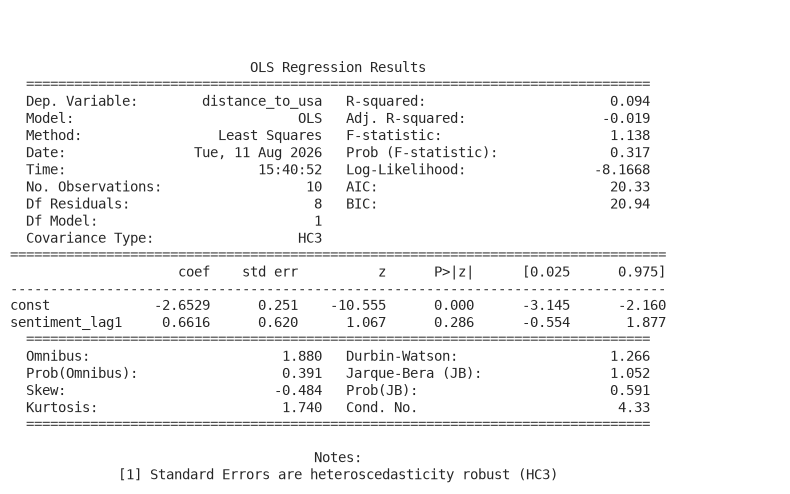

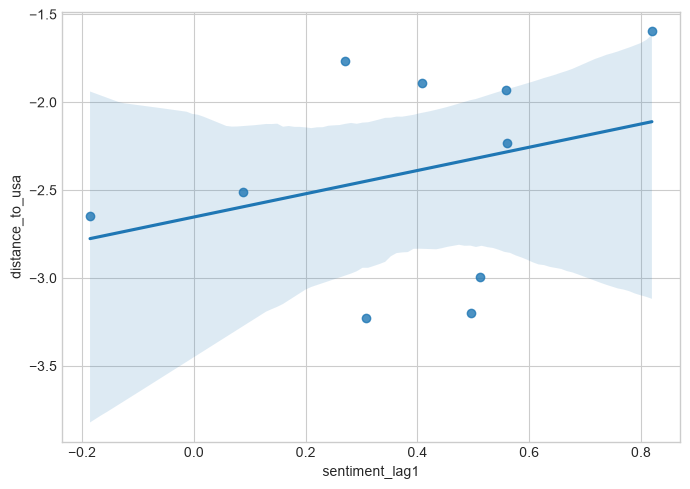

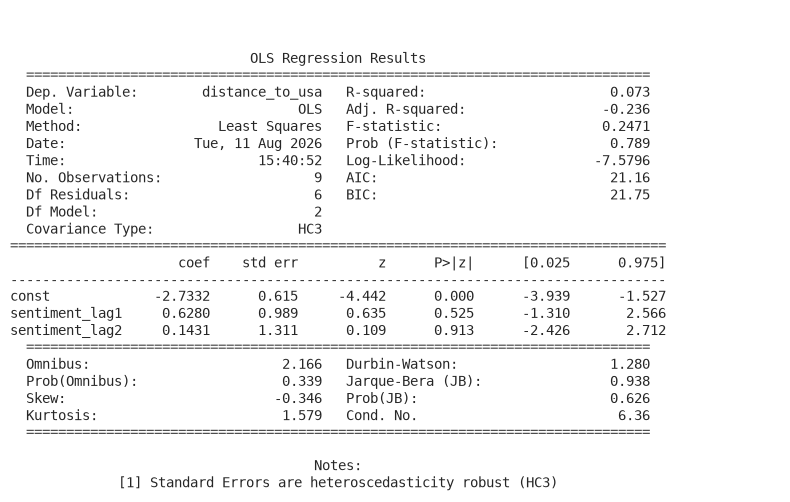

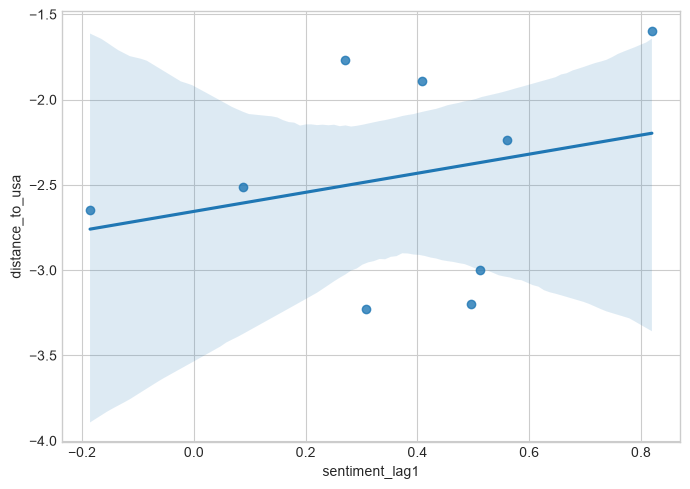

In [ ]:
results = reg.perform_sentiment_regressions(
    filtered_distance_USA,
    country="AUS"
)